# Telco Customer Churn — End-to-End Classification Project

A complete, reproducible machine learning workflow for predicting customer churn using the
[IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) dataset
(7,043 customers, 21 columns, binary target `Churn`).

**Pipeline:** Problem framing → EDA → Outlier review → Feature engineering → Preprocessing →
Train/test split → Baseline model → Class-imbalance handling → Model comparison → Cross-validation →
Hyperparameter tuning → Bias/variance diagnostics → Metrics → Calibration → Interpretability →
Model selection → Error analysis → Save & serve → Experiment log

**Tech stack:** pandas, scikit-learn, imbalanced-learn, statsmodels, seaborn/matplotlib.

## 1. Problem Framing

This is a **binary classification** problem: predict whether a customer will churn (`Yes`/`No`).

| Error type | What it means | Business cost |
|---|---|---|
| **False Positive** | Model predicts churn, customer would have stayed | Wasted retention offer (discount, call center time) |
| **False Negative** | Model predicts "stays", customer actually churns | Lost recurring revenue, plus the cost of re-acquiring a replacement customer |

In subscription businesses, a missed churner (False Negative) is usually more expensive than an
unnecessary retention offer (False Positive) — acquiring a new customer typically costs several
times more than retaining an existing one. That means **Recall** (catching as many true churners as
possible) is prioritized somewhat over **Precision**, without ignoring precision entirely since
retention budgets aren't infinite. **F1-score** is used as the primary tuning/CV metric because it
balances both, and **ROC-AUC** / **Precision-Recall AUC** are tracked to judge overall ranking quality.

- **Problem type:** Binary classification
- **Target column:** `Churn` (`Yes` / `No`)
- **Primary metric:** F1-score (with Recall and ROC-AUC as supporting metrics)

## 2. Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1 Fix `TotalCharges` dtype

`TotalCharges` looks numeric but loads as an `object` column — a sign that some cells contain blank
strings instead of numbers (new customers with `tenure == 0` have no total billed yet).
`pd.to_numeric(..., errors="coerce")` converts those blanks to `NaN` so they can be imputed properly
in the preprocessing pipeline, rather than silently mis-parsed.

In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [4]:
df.isnull().sum()[df.isnull().sum() > 0]

TotalCharges    11
dtype: int64

In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


### 2.2 Target class balance

~73% of customers stay and ~27% churn. That's a moderate imbalance — not extreme, but enough that
accuracy alone would be a misleading metric (a model that always predicts "No" would score ~73%
accuracy while catching zero churners). This is why Section 8 explicitly addresses imbalance and why
F1/Recall are used instead of raw accuracy.

In [6]:
df["Churn"].value_counts(normalize=True).round(4)

Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64

### 2.3 Numeric feature distributions

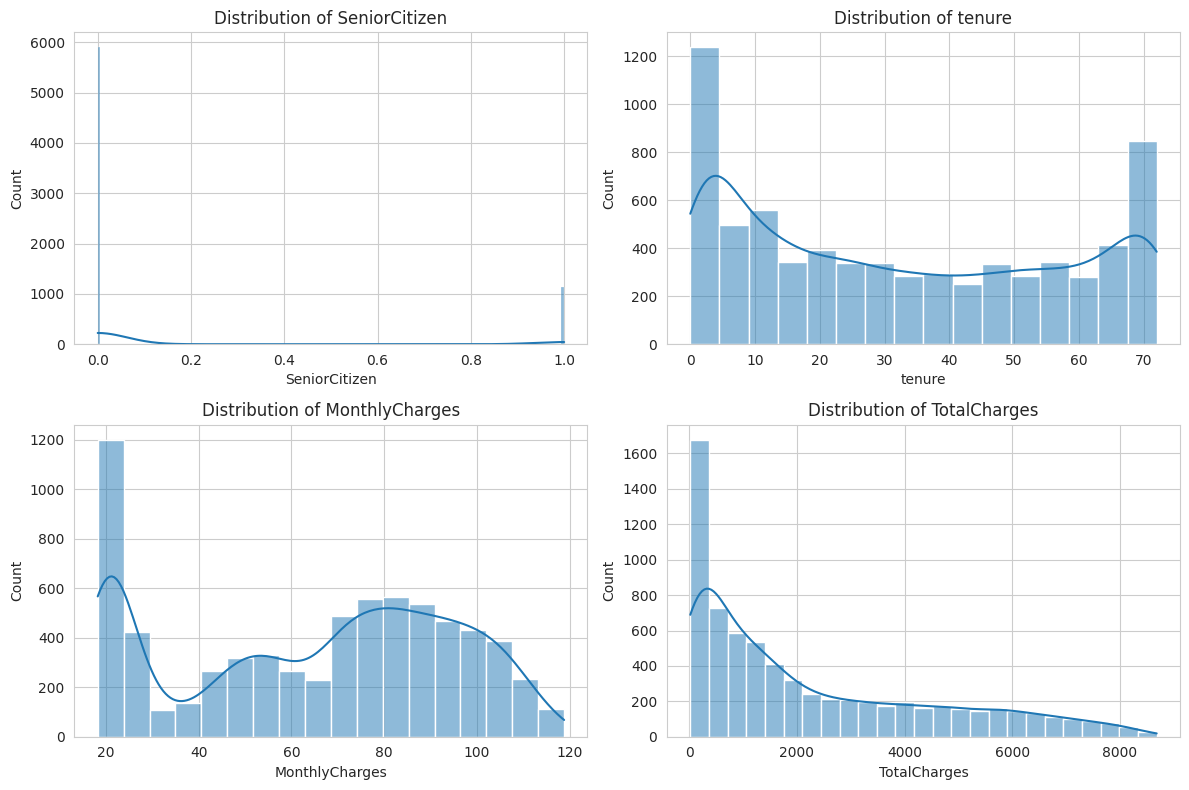

In [7]:
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
fig.tight_layout()
plt.show()

`tenure` is roughly bimodal (a large group of very new customers and another of long-tenured ones).
`MonthlyCharges` is bimodal too, reflecting distinct pricing tiers. `TotalCharges` is right-skewed,
which follows naturally from `TotalCharges ≈ tenure × MonthlyCharges`.

### 2.4 Categorical feature counts

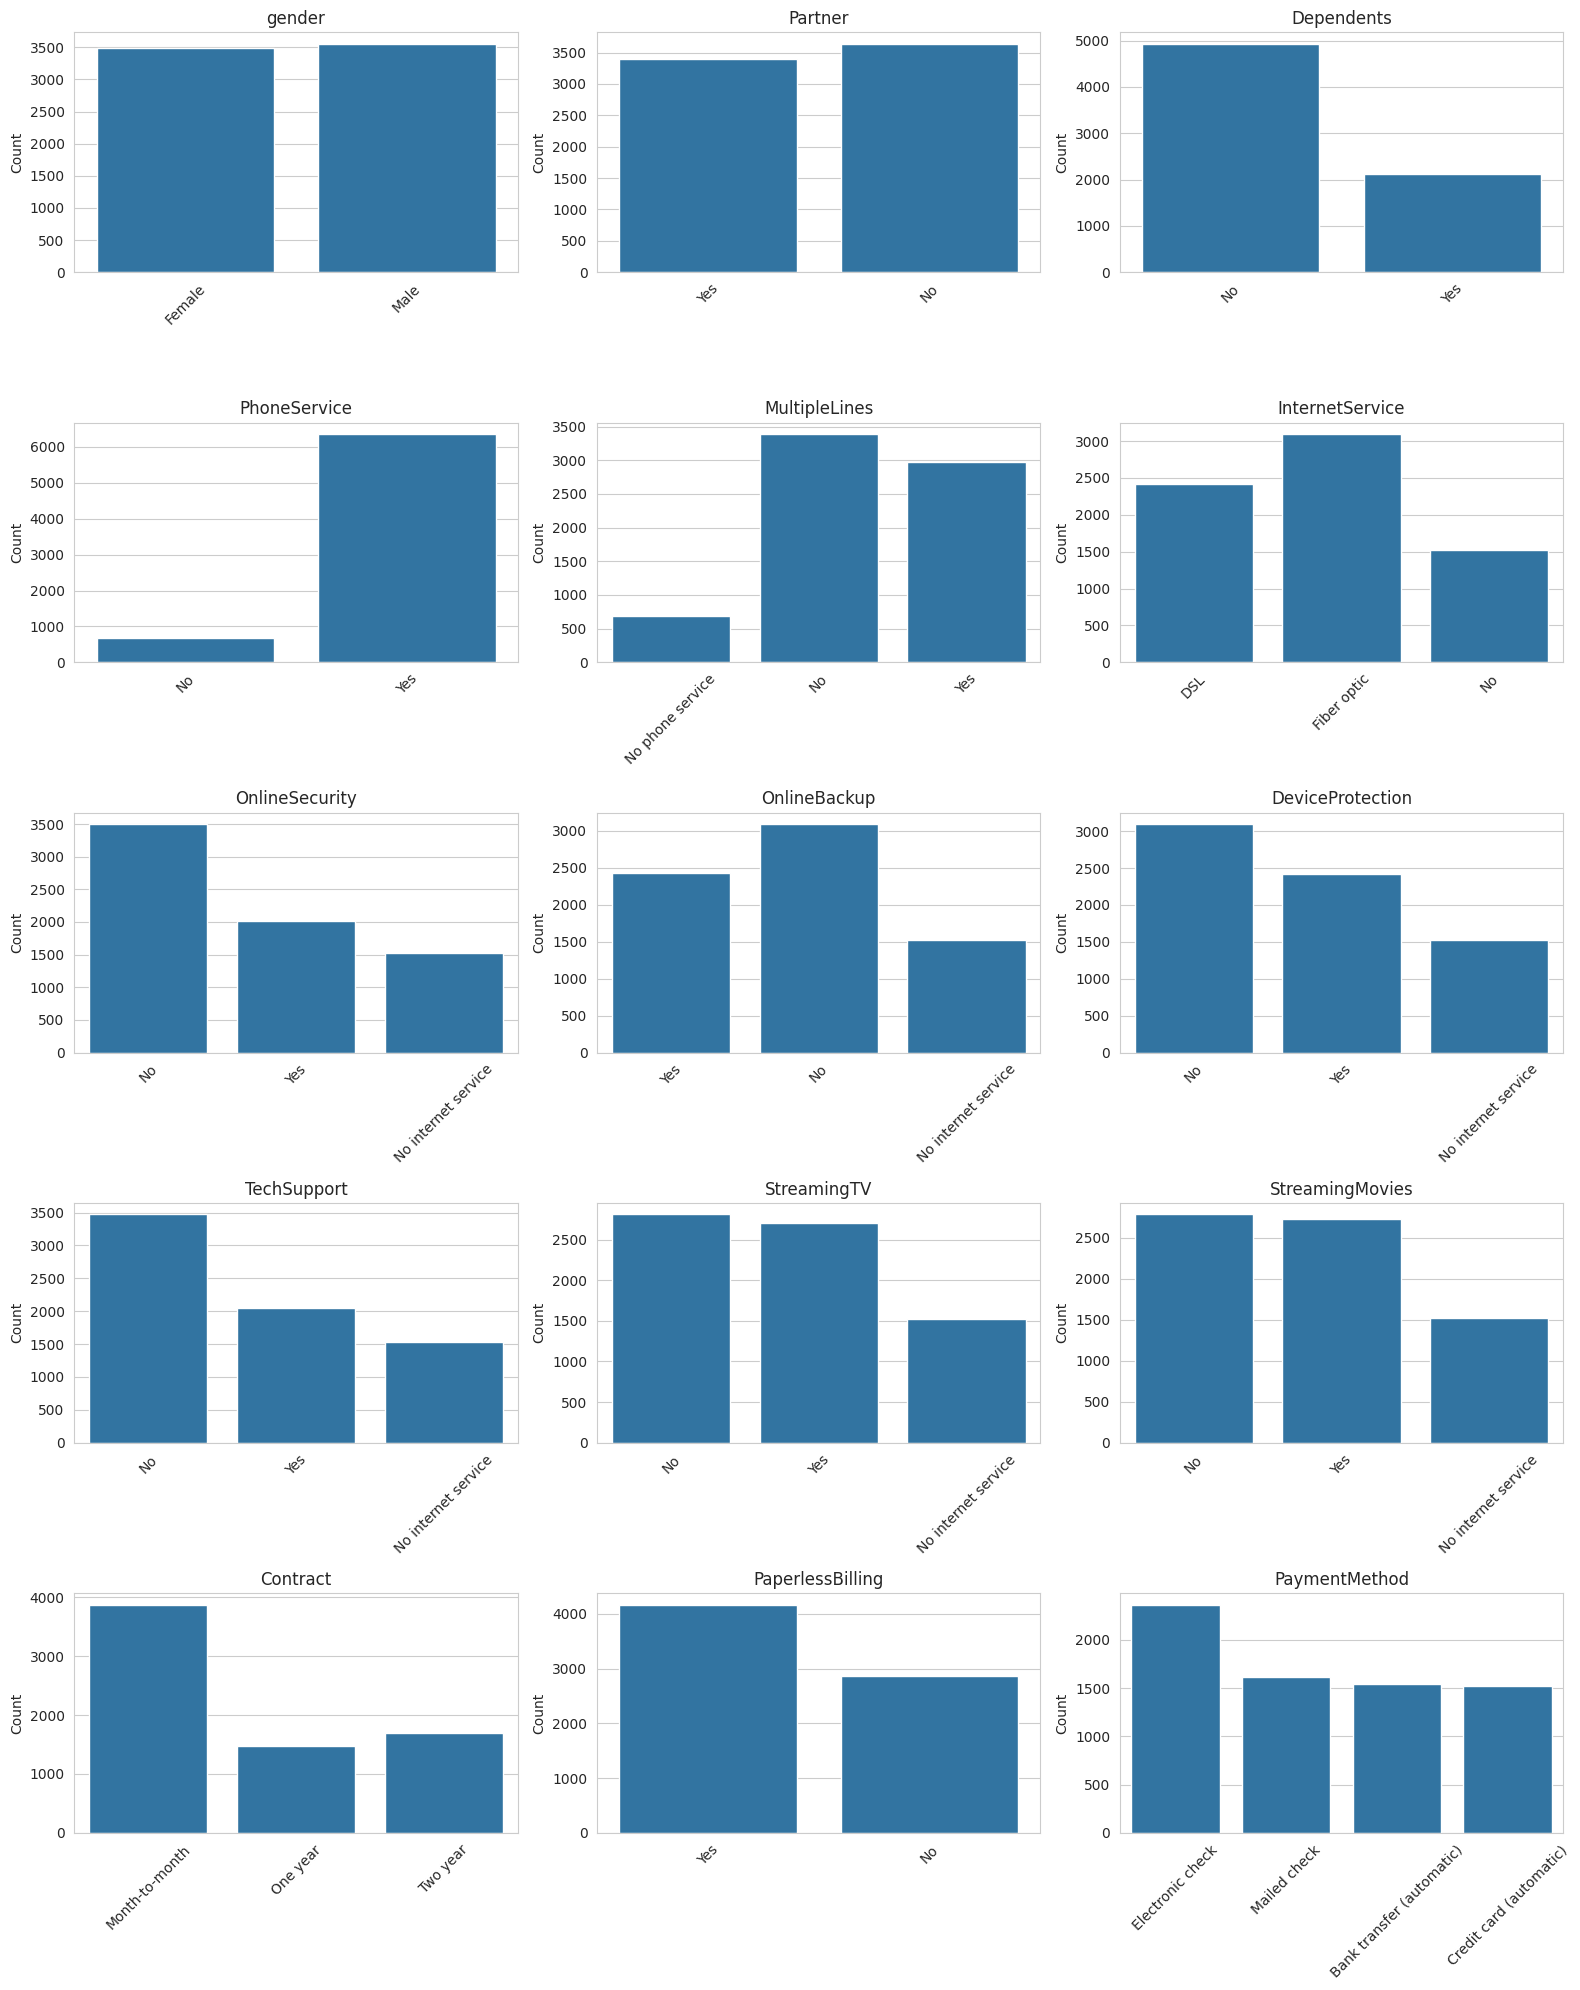

In [8]:
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod",
]

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
for ax, col in zip(axes.ravel(), categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

### 2.5 Correlation of numeric features with churn

`Churn` is text (`Yes`/`No`), so it's mapped to `1`/`0` in a separate copy of the dataframe purely
for correlation/statistical analysis — the original `df` is left untouched at this stage.

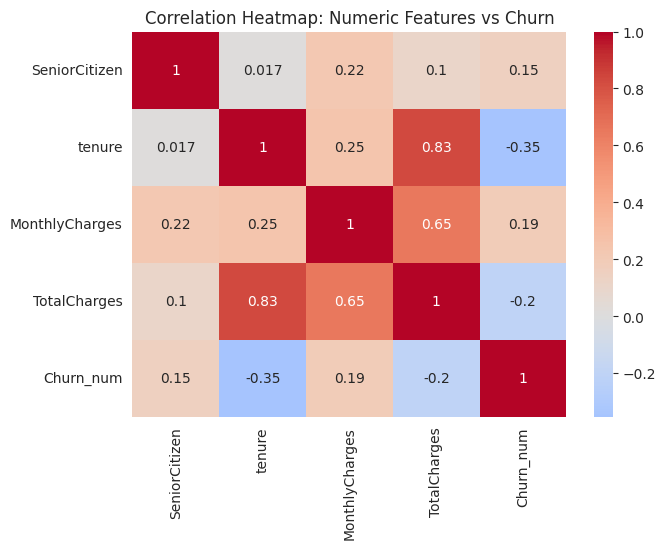

Churn_num         1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_num, dtype: float64

In [9]:
df_corr = df.copy()
df_corr["Churn_num"] = df_corr["Churn"].map({"Yes": 1, "No": 0})

corr = df_corr[numeric_cols + ["Churn_num"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Numeric Features vs Churn")
plt.show()

corr["Churn_num"].sort_values(ascending=False)

`tenure` has the strongest (negative) correlation with churn — customers who've stayed longer are
less likely to leave. `MonthlyCharges` correlates positively (pricier plans churn more).
`TotalCharges` correlates negatively, but that's largely confounded with `tenure`
(`TotalCharges ≈ tenure × MonthlyCharges`) — this multicollinearity is investigated formally in
Section 4 (VIF).

### 2.6 Chi-square test: categorical features vs churn

The chi-square test of independence checks whether a categorical feature and the target are
statistically associated. A p-value below 0.05 means the association is unlikely to be due to chance.

In [10]:
from scipy.stats import chi2_contingency

p_values = {}
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = chi2_contingency(contingency_table, correction=True)
    p_values[col] = p

print("Features ranked by association with churn (ascending p-value):\n")
for col, p in sorted(p_values.items(), key=lambda x: x[1]):
    flag = "significant (p < 0.05)" if p < 0.05 else "not significant"
    print(f"  {col:<20} p = {p:.6f}   {flag}")

Features ranked by association with churn (ascending p-value):

  Contract             p = 0.000000   significant (p < 0.05)
  OnlineSecurity       p = 0.000000   significant (p < 0.05)
  TechSupport          p = 0.000000   significant (p < 0.05)
  InternetService      p = 0.000000   significant (p < 0.05)
  PaymentMethod        p = 0.000000   significant (p < 0.05)
  OnlineBackup         p = 0.000000   significant (p < 0.05)
  DeviceProtection     p = 0.000000   significant (p < 0.05)
  StreamingMovies      p = 0.000000   significant (p < 0.05)
  StreamingTV          p = 0.000000   significant (p < 0.05)
  PaperlessBilling     p = 0.000000   significant (p < 0.05)
  Dependents           p = 0.000000   significant (p < 0.05)
  Partner              p = 0.000000   significant (p < 0.05)
  MultipleLines        p = 0.003464   significant (p < 0.05)
  PhoneService         p = 0.338783   not significant
  gender               p = 0.486579   not significant


`Contract`, `InternetService`, `OnlineSecurity`, `TechSupport`, and `PaymentMethod` all come back
strongly significant — these are exactly the features that dominate the feature-importance ranking
in Section 15, which is a good internal-consistency check on the whole pipeline. Only `gender` fails
to show a significant association, matching general domain expectation (churn drivers here are
contractual/service-related, not demographic).

### 2.7 Numeric features vs churn class (boxplots)

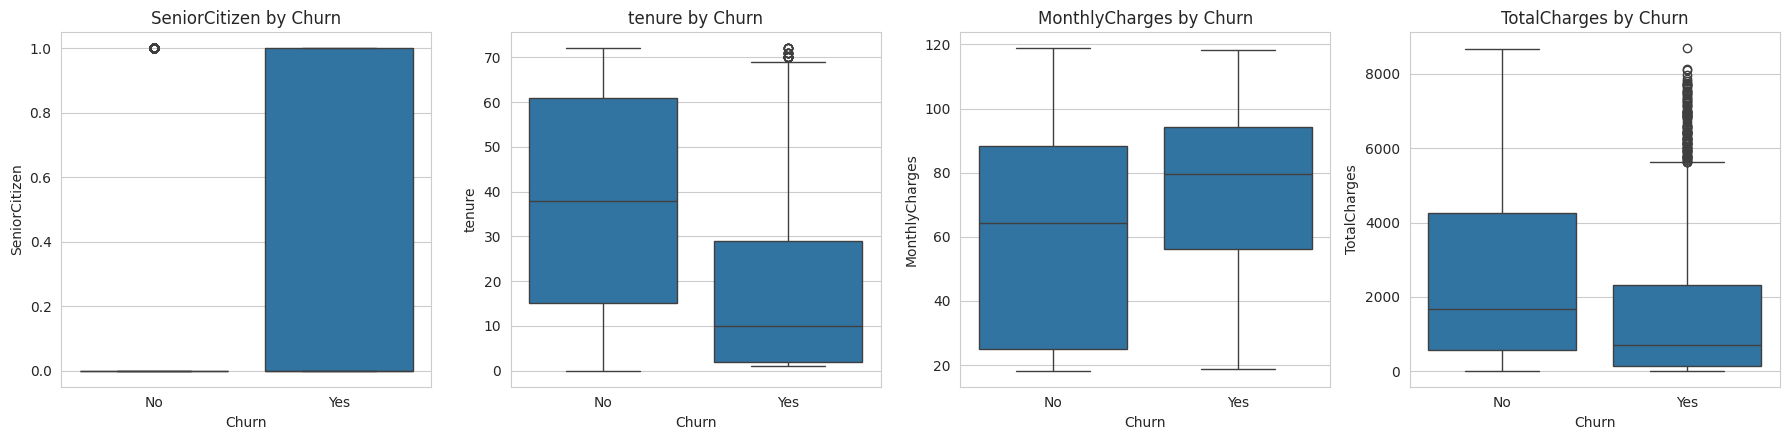

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} by Churn")
fig.tight_layout()
plt.show()

`tenure` shows the clearest separation — churners are concentrated at low tenure. `MonthlyCharges`
is visibly higher for churners. `TotalCharges` separates less cleanly on its own, again because it's
a product of the other two.

## 3. Outlier Handling

Boxplots below (no `hue`, raw distribution) check `tenure`, `MonthlyCharges`, `TotalCharges` for
points far outside the whiskers.

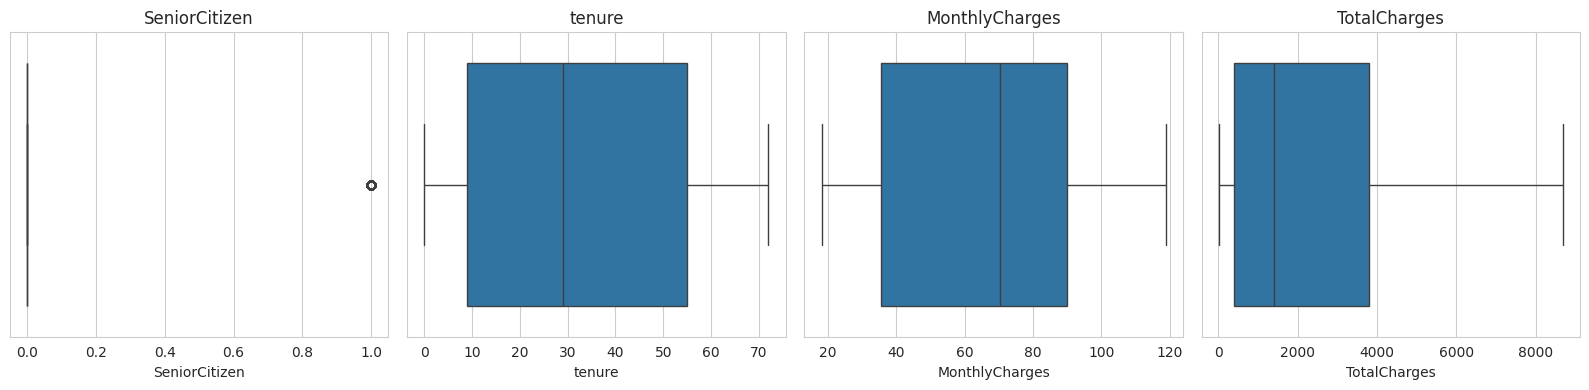

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
fig.tight_layout()
plt.show()

**Decision: keep all rows, no capping or removal.** None of the numeric columns show genuine
outliers (impossible values, data-entry errors, or a handful of extreme points far from the rest).
What looks like spread in the boxplots is ordinary **right/left skew** from real, valid business
variation (billing tiers, tenure length) — not bad data. Tree-based models (Random Forest, Gradient
Boosting), which end up performing best in Section 16, are also largely insensitive to this kind of
skew, so no transformation is necessary for this project.

## 4. Feature Engineering

Two new features are engineered from existing columns:
- **`AvgMonthlyCharge`** — `TotalCharges / tenure`, i.e. the customer's realized average monthly
  spend over their lifetime so far (guards against divide-by-zero for `tenure == 0` by treating it
  as missing rather than infinite).
- **`TenureGroup`** — `tenure` bucketed into `0-1yr / 1-2yr / 2-4yr / 4-6yr` bands, letting
  tree-based models split on a coarser, more human-interpretable tenure signal.

In [13]:
df_fe = df.copy()

df_fe["AvgMonthlyCharge"] = df_fe["TotalCharges"] / df_fe["tenure"].replace(0, np.nan)

df_fe["TenureGroup"] = pd.cut(
    df_fe["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"],
)

df_fe[["tenure", "TotalCharges", "MonthlyCharges", "AvgMonthlyCharge", "TenureGroup"]].head()

,tenure,TotalCharges,MonthlyCharges,AvgMonthlyCharge,TenureGroup
0,1,29.85,29.85,29.850000,0-1yr
1,34,1889.50,56.95,55.573529,2-4yr
2,2,108.15,53.85,54.075000,0-1yr
3,45,1840.75,42.30,40.905556,2-4yr
4,2,151.65,70.70,75.825000,0-1yr


### 4.1 Multicollinearity check (VIF)

Variance Inflation Factor quantifies how much a feature's variance is inflated by its linear
relationship with the other numeric features. VIF > 5 is a commonly used "worth investigating"
threshold, and VIF > 10 is generally considered problematic (mainly for linear/distance-based
models — tree-based models are unaffected by multicollinearity).

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols_vif = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlyCharge"]
vif_data = df_fe[numeric_cols_vif].dropna()

vif_df = pd.DataFrame()
vif_df["Feature"] = vif_data.columns
vif_df["VIF"] = [
    variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])
]
vif_df.sort_values("VIF", ascending=False)

,Feature,VIF
2,MonthlyCharges,749.201846
4,AvgMonthlyCharge,748.499820
3,TotalCharges,8.102047
1,tenure,6.339413
0,SeniorCitizen,1.257874


`TotalCharges`, `MonthlyCharges`, and the engineered `AvgMonthlyCharge` show very high VIF — expected,
since `AvgMonthlyCharge` is mathematically derived from the other two. **Decision:** the engineered
features are kept for the EDA/analysis narrative above, but are **not added to the modeling
pipeline** in Section 5 — including them would just reintroduce redundant, highly collinear signal
that the original `tenure`/`MonthlyCharges`/`TotalCharges` columns already provide, without adding
real predictive information. This is a real, common outcome of feature engineering: not every
engineered feature earns a place in the final model.

## 5. Preprocessing

All preprocessing is built as a single `ColumnTransformer` wrapped in a `Pipeline`, so it can be
`fit` **only on training data** and `transform`ed onto both train and test — avoiding data leakage.
Numeric columns are median-imputed and standardized (needed for Logistic Regression / KNN / SVM,
harmless for tree-based models). Categorical columns are mode-imputed and one-hot encoded, since the
Telco categorical columns (`Contract`, `InternetService`, `PaymentMethod`, etc.) are nominal — no
inherent order — so `OneHotEncoder` is the correct choice over `LabelEncoder`.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

df = df.drop(columns=["customerID"])  # identifier, not a predictive feature

numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

## 6. Train / Test Split

A held-out 20% test set is stratified on `Churn` so the class ratio matches the full dataset in both
splits — important given the ~73/27 imbalance. Model selection during development relies on
**5-fold `StratifiedKFold` cross-validation on the training set** (Section 10) rather than a second
fixed validation split, since CV gives a mean *and* a standard deviation across five different train/
validation slices — a more robust signal than any single split, especially on a dataset this size.
The test set stays completely untouched until final evaluation (Section 13) and error analysis.

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")

Train: (5634, 19), Test: (1409, 19)
Train churn rate: 0.265, Test churn rate: 0.265


## 7. Baseline Model

A single, un-tuned Logistic Regression establishes an honest number to beat and proves the pipeline
runs end-to-end before adding any complexity. `max_iter` is raised from the default because the
scaled-but-still-wide one-hot-encoded feature space can need more iterations to converge.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

print("=== Baseline Logistic Regression ===")
print(classification_report(y_test, baseline_pred))

=== Baseline Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 8. Handle Class Imbalance

Two standard fixes are compared against the baseline:
- **`class_weight="balanced"`** — penalizes mistakes on the minority (churn) class more heavily,
  without touching the training data itself.
- **SMOTE** — generates *synthetic* minority-class examples (rather than duplicating existing rows)
  to rebalance the training set. SMOTE is applied through an `imblearn.pipeline.Pipeline` (not
  plain sklearn `Pipeline`), which is essential: it guarantees SMOTE only ever touches the *training*
  fold, after preprocessing, and is automatically skipped at prediction time — preventing leakage
  from synthetic points into validation/test data.

In [18]:
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)

print("=== Balanced Logistic Regression (class_weight='balanced') ===")
print(classification_report(y_test, balanced_pred))

=== Balanced Logistic Regression (class_weight='balanced') ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [19]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000)),
])

smote_pipeline.fit(X_train, y_train)
smote_pred = smote_pipeline.predict(X_test)

print("=== SMOTE Logistic Regression ===")
print(classification_report(y_test, smote_pred))

=== SMOTE Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline": [
        accuracy_score(y_test, baseline_pred), precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred), f1_score(y_test, baseline_pred),
    ],
    "class_weight='balanced'": [
        accuracy_score(y_test, balanced_pred), precision_score(y_test, balanced_pred),
        recall_score(y_test, balanced_pred), f1_score(y_test, balanced_pred),
    ],
    "SMOTE": [
        accuracy_score(y_test, smote_pred), precision_score(y_test, smote_pred),
        recall_score(y_test, smote_pred), f1_score(y_test, smote_pred),
    ],
})
comparison.round(4)

,Metric,Baseline,class_weight='balanced',SMOTE
0,Accuracy,0.8055,0.7381,0.7374
1,Precision,0.6572,0.5043,0.5034
2,Recall,0.5588,0.7834,0.7941
3,F1-Score,0.6040,0.6136,0.6162


Both imbalance-handling strategies trade some precision for a clear recall gain over the baseline —
exactly the trade-off Section 1 argued for. `class_weight="balanced"` is carried forward as the
default imbalance strategy for the remaining models below, since it needs no extra pipeline step and
performs comparably to SMOTE here.

## 9. Models to Train & Compare

Six model families, each with a different bias and sensitivity profile:

| Model | Core idea | Sensitive to |
|---|---|---|
| Logistic Regression (L1) | Linear decision boundary, L1 can zero out weak features | Feature scale |
| Logistic Regression (L2) | Linear decision boundary, L2 shrinks all weights | Feature scale |
| KNN | Classifies by nearest neighbors' majority vote | Feature scale strongly |
| Decision Tree | Splits on feature thresholds | Overfitting if unconstrained |
| Random Forest | Ensemble of many decorrelated trees, averaged | Less sensitive to most issues |
| Gradient Boosting | Trees built sequentially, each correcting the last | Learning rate / depth |

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "LogReg_L1": LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced", max_iter=1000),
    "LogReg_L2": LogisticRegression(penalty="l2", class_weight="balanced", max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

## 10. Cross-Validation

Each model is wrapped with the shared `preprocessor` and evaluated with 5-fold `StratifiedKFold`
(stratified again here for the same imbalance reason as the train/test split), scored on **F1**
rather than accuracy for the reasons established in Section 1. Both the mean *and* the standard
deviation are tracked — a slightly lower mean with much lower variance can be the more trustworthy
model in production.

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, clf in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<18} Mean F1: {scores.mean():.4f}   Std F1: {scores.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

LogReg_L1          Mean F1: 0.6281   Std F1: 0.0220


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


LogReg_L2          Mean F1: 0.6279   Std F1: 0.0232


KNN                Mean F1: 0.5471   Std F1: 0.0152


DecisionTree       Mean F1: 0.5053   Std F1: 0.0140


RandomForest       Mean F1: 0.5380   Std F1: 0.0249


GradientBoosting   Mean F1: 0.5902   Std F1: 0.0227


## 11. Hyperparameter Tuning

`GridSearchCV` exhaustively searches each grid using the same `StratifiedKFold` splitter and `F1`
scoring as Section 10, so results are directly comparable. Note the `classifier__` prefix on every
parameter name — required because the estimator being tuned is a `Pipeline`, and this syntax tells
`GridSearchCV` which step's parameter to set.

The three strongest/most tunable candidates from Section 10 are tuned: Random Forest, Gradient
Boosting, and Logistic Regression (regularization strength `C`).

In [23]:
from sklearn.model_selection import GridSearchCV

# --- Random Forest ---
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42)),
])
rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4],
}
rf_search = GridSearchCV(rf_pipe, rf_param_grid, cv=skf, scoring="f1", n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Random Forest  | best params:", rf_search.best_params_)
print("Random Forest  | best CV F1 :", round(rf_search.best_score_, 4))

Random Forest  | best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
Random Forest  | best CV F1 : 0.6333


In [24]:
# --- Gradient Boosting ---
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42)),
])
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [2, 3, 4],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
}
gb_search = GridSearchCV(gb_pipe, gb_param_grid, cv=skf, scoring="f1", n_jobs=-1)
gb_search.fit(X_train, y_train)
print("Grad. Boosting | best params:", gb_search.best_params_)
print("Grad. Boosting | best CV F1 :", round(gb_search.best_score_, 4))

Grad. Boosting | best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Grad. Boosting | best CV F1 : 0.5902


In [25]:
# --- Logistic Regression (regularization strength C) ---
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
lr_param_grid = {"classifier__C": [0.01, 0.1, 1, 10, 100]}
lr_search = GridSearchCV(lr_pipe, lr_param_grid, cv=skf, scoring="f1", n_jobs=-1)
lr_search.fit(X_train, y_train)
print("Logistic Reg.  | best params:", lr_search.best_params_)
print("Logistic Reg.  | best CV F1 :", round(lr_search.best_score_, 4))

Logistic Reg.  | best params: {'classifier__C': 0.1}
Logistic Reg.  | best CV F1 : 0.6295


## 12. Bias-Variance Diagnostics

Learning curves plot train vs. cross-validation F1 as training-set size grows. A large, persistent
gap between the two curves signals **overfitting** (high variance); both curves being low and close
together signals **underfitting** (high bias).

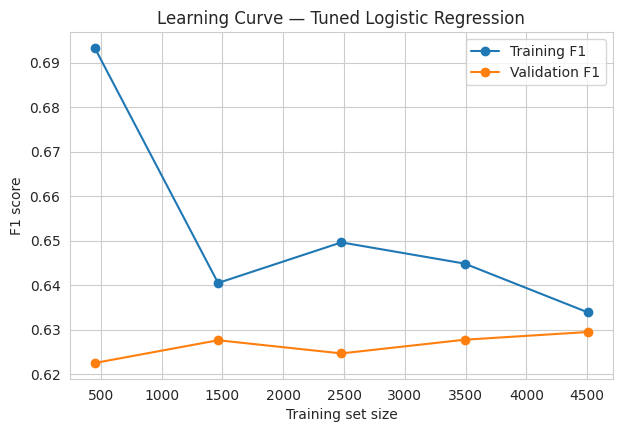

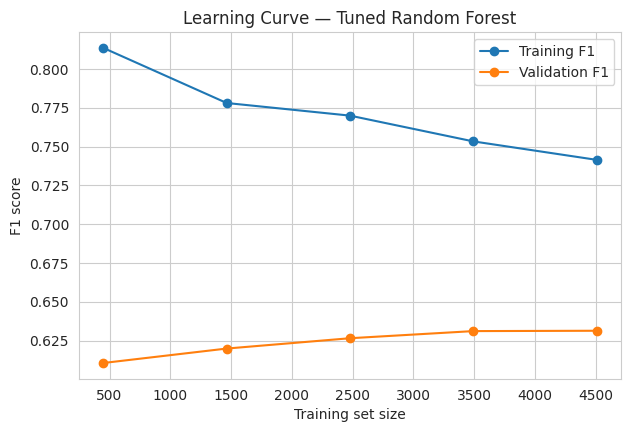

In [26]:
from sklearn.model_selection import learning_curve


def plot_learning_curve(estimator, X, y, model_name):
    train_sizes, train_scores, cv_scores = learning_curve(
        estimator=estimator, X=X, y=y, cv=skf, scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1,
    )
    plt.figure(figsize=(7, 4.5))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training F1")
    plt.plot(train_sizes, cv_scores.mean(axis=1), marker="o", label="Validation F1")
    plt.title(f"Learning Curve — {model_name}")
    plt.xlabel("Training set size")
    plt.ylabel("F1 score")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_learning_curve(lr_search.best_estimator_, X_train, y_train, "Tuned Logistic Regression")
plot_learning_curve(rf_search.best_estimator_, X_train, y_train, "Tuned Random Forest")

### Deliberate overfit vs. underfit example

To make the concept concrete: an unconstrained Decision Tree (no depth limit, `min_samples_leaf=1`)
vs. a heavily restricted one (`max_depth=1`).

In [27]:
overfit_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=42)),
])
overfit_tree.fit(X_train, y_train)
print("=== Overfit Tree (unconstrained) ===")
print(f"Train accuracy: {overfit_tree.score(X_train, y_train):.4f}")
print(f"Test accuracy : {overfit_tree.score(X_test, y_test):.4f}")

underfit_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=1, min_samples_leaf=50, random_state=42)),
])
underfit_tree.fit(X_train, y_train)
print("\n=== Underfit Tree (max_depth=1) ===")
print(f"Train accuracy: {underfit_tree.score(X_train, y_train):.4f}")
print(f"Test accuracy : {underfit_tree.score(X_test, y_test):.4f}")

=== Overfit Tree (unconstrained) ===
Train accuracy: 0.9980
Test accuracy : 0.7289

=== Underfit Tree (max_depth=1) ===
Train accuracy: 0.7346
Test accuracy : 0.7346


The unconstrained tree shows a wide train/test gap — classic overfitting (it memorizes training
rows). The depth-1 tree scores similarly low on both — classic underfitting (too simple to capture
the pattern). The tuned Random Forest and Gradient Boosting models above sit in between: strong
training performance without a large drop-off on validation.

## 13. Metrics — Full Evaluation on the Test Set

Every tuned/baseline model is scored on the held-out test set with a common set of metrics:
Accuracy, Precision, Recall, F1, ROC-AUC, and Log Loss, plus a confusion matrix, ROC curve, and
Precision-Recall curve. The PR curve is tracked alongside ROC because it's typically more
informative than ROC when the positive class is the minority class, as it is here.


Baseline Logistic Regression
Accuracy  : 0.8055
Precision : 0.6572
Recall    : 0.5588
F1        : 0.6040
AUC       : 0.8419
LogLoss   : 0.4205

Balanced Logistic Regression
Accuracy  : 0.7381
Precision : 0.5043
Recall    : 0.7834
F1        : 0.6136
AUC       : 0.8413
LogLoss   : 0.4969

SMOTE Logistic Regression
Accuracy  : 0.7374
Precision : 0.5034
Recall    : 0.7941
F1        : 0.6162
AUC       : 0.8401
LogLoss   : 0.4940

Logistic Regression (tuned)
Accuracy  : 0.7424
Precision : 0.5095
Recall    : 0.7861
F1        : 0.6183
AUC       : 0.8409
LogLoss   : 0.4975


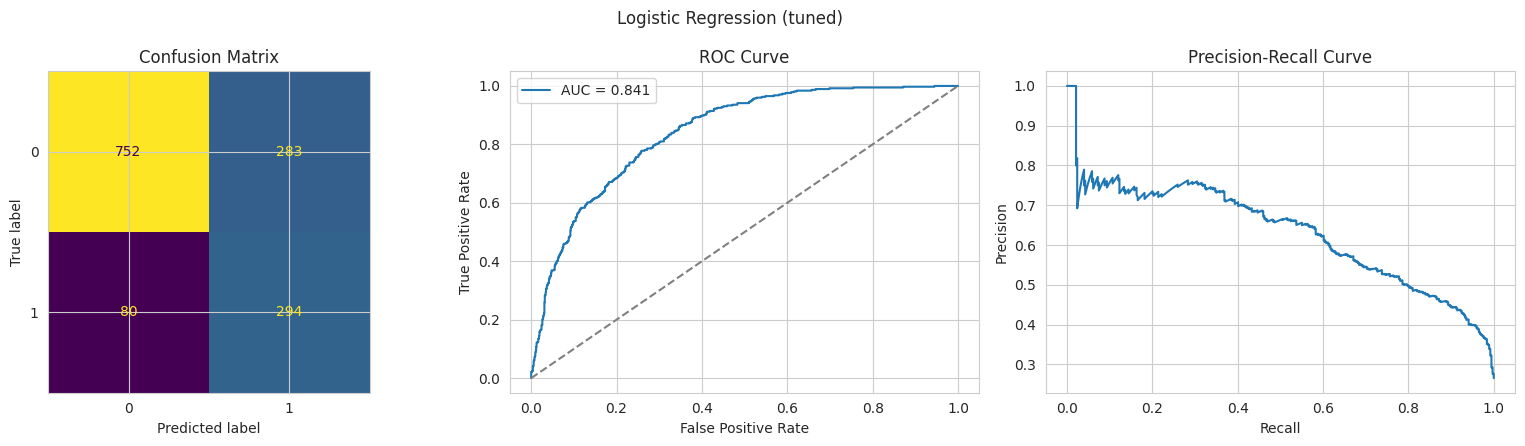


Random Forest (tuned)
Accuracy  : 0.7672
Precision : 0.5446
Recall    : 0.7513
F1        : 0.6315
AUC       : 0.8411
LogLoss   : 0.4651


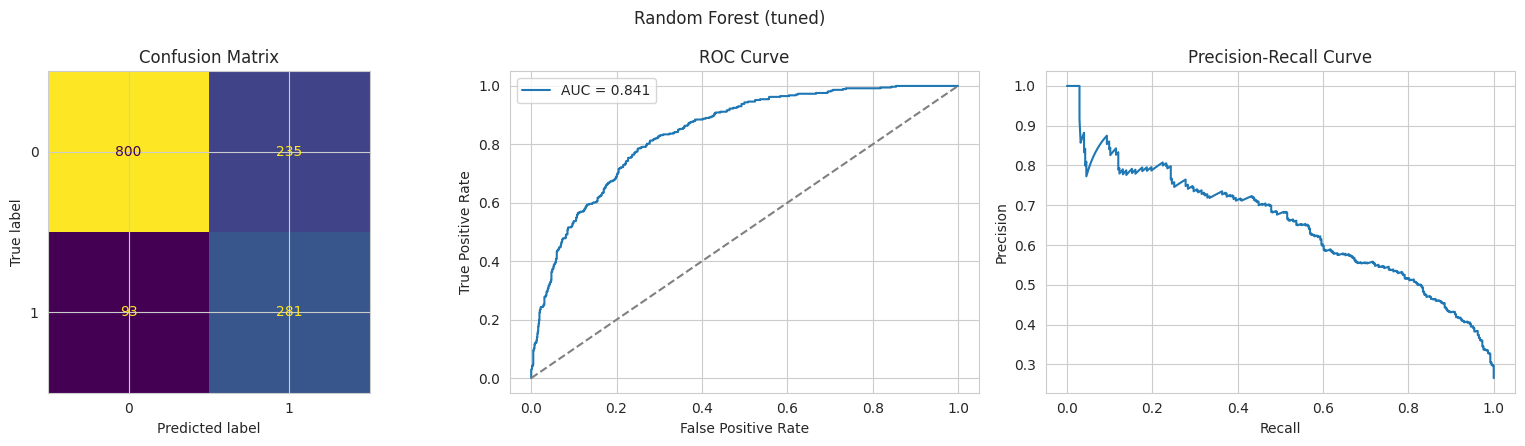


Gradient Boosting (tuned)
Accuracy  : 0.8062
Precision : 0.6735
Recall    : 0.5241
F1        : 0.5895
AUC       : 0.8434
LogLoss   : 0.4178


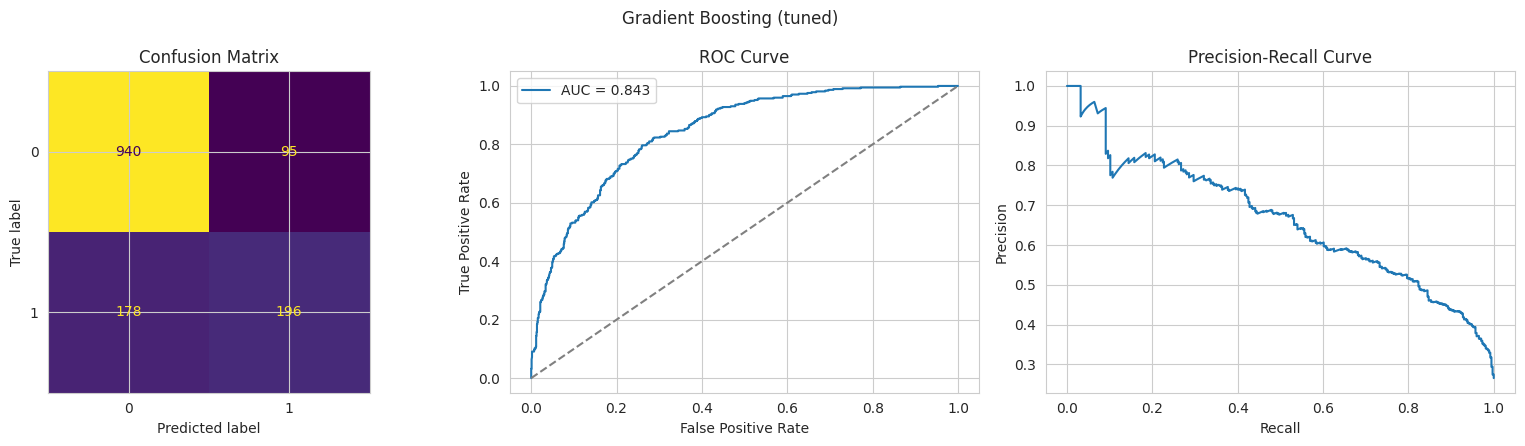

{'Accuracy': 0.8062455642299503,
 'Precision': 0.6735395189003437,
 'Recall': 0.5240641711229946,
 'F1': 0.5894736842105263,
 'AUC': 0.8433620088351547,
 'LogLoss': 0.41776823329351387}

In [28]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, log_loss, ConfusionMatrixDisplay,
)

evaluation_results = {}


def evaluate_model(name, pipe, X_test, y_test, plot=True):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "LogLoss": log_loss(y_test, y_proba),
    }
    evaluation_results[name] = metrics

    print(f"\n{'=' * 55}\n{name}\n{'=' * 55}")
    for k, v in metrics.items():
        print(f"{k:<10}: {v:.4f}")

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
        axes[0].set_title("Confusion Matrix")

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        axes[1].plot(fpr, tpr, label=f"AUC = {metrics['AUC']:.3f}")
        axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].set_title("ROC Curve")
        axes[1].legend()

        prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
        axes[2].plot(rec_vals, prec_vals)
        axes[2].set_xlabel("Recall")
        axes[2].set_ylabel("Precision")
        axes[2].set_title("Precision-Recall Curve")

        fig.suptitle(name)
        fig.tight_layout()
        plt.show()

    return metrics


evaluate_model("Baseline Logistic Regression", baseline_pipeline, X_test, y_test, plot=False)
evaluate_model("Balanced Logistic Regression", balanced_pipeline, X_test, y_test, plot=False)
evaluate_model("SMOTE Logistic Regression", smote_pipeline, X_test, y_test, plot=False)
evaluate_model("Logistic Regression (tuned)", lr_search, X_test, y_test)
evaluate_model("Random Forest (tuned)", rf_search, X_test, y_test)
evaluate_model("Gradient Boosting (tuned)", gb_search, X_test, y_test)

## 14. Calibration

A model can rank customers correctly (good AUC) while its predicted *probabilities* are untrustworthy
— e.g. saying "90% likely to churn" for customers who actually churn only 60% of the time. The
calibration curve bins predictions by predicted probability and compares against the actual observed
churn rate in each bin; a perfectly calibrated model sits on the diagonal `y = x`.

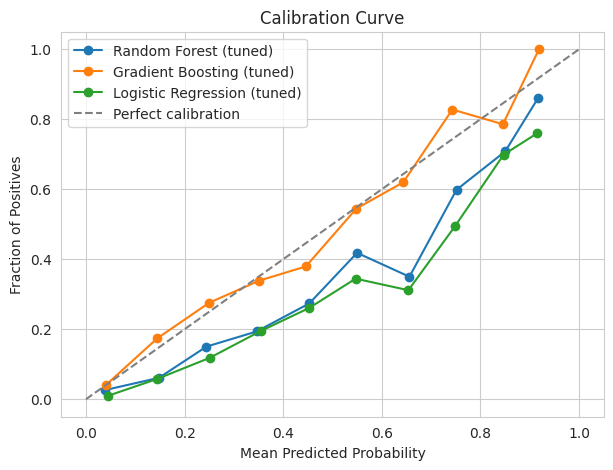

In [29]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(7, 5))
for name, pipe in [
    ("Random Forest (tuned)", rf_search),
    ("Gradient Boosting (tuned)", gb_search),
    ("Logistic Regression (tuned)", lr_search),
]:
    prob_true, prob_pred = calibration_curve(y_test, pipe.predict_proba(X_test)[:, 1], n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

All three tuned models track the diagonal reasonably closely across most bins, meaning their
predicted churn probabilities are broadly trustworthy as-is — useful if the business wants to rank
customers by *risk score*, not just a binary churn/no-churn label (e.g. prioritizing retention
outreach by probability).

## 15. Model Interpretability

Two complementary views on feature importance for the tuned Random Forest: the model's own
`feature_importances_` (fast, but can be biased toward high-cardinality one-hot columns), and
**permutation importance** (model-agnostic: shuffle one feature at a time and measure the drop in
F1 — more reliable when comparing across encoded categorical vs numeric features).

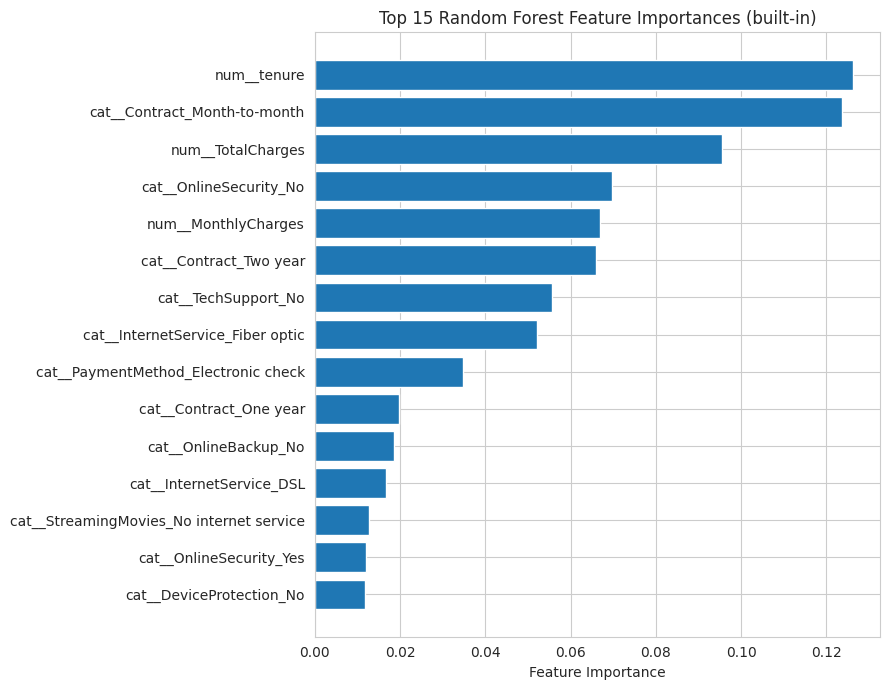

In [30]:
best_rf = rf_search.best_estimator_
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 7))
plt.barh(
    feature_importance_df["Feature"].head(15)[::-1],
    feature_importance_df["Importance"].head(15)[::-1],
)
plt.xlabel("Feature Importance")
plt.title("Top 15 Random Forest Feature Importances (built-in)")
plt.tight_layout()
plt.show()

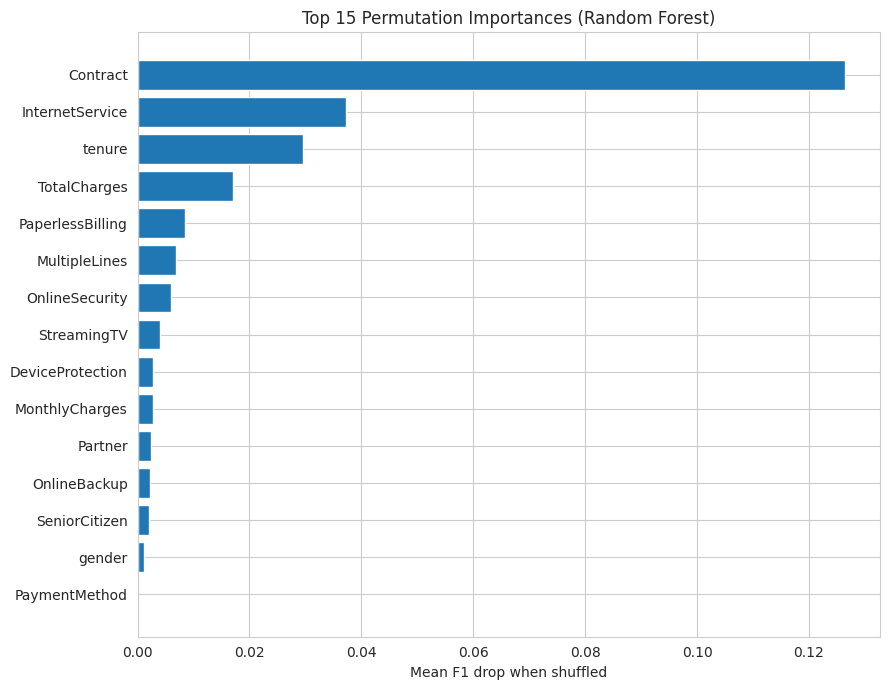

In [31]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring="f1", n_jobs=-1
)
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_result.importances_mean,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 7))
plt.barh(perm_df["Feature"].head(15)[::-1], perm_df["Importance"].head(15)[::-1])
plt.xlabel("Mean F1 drop when shuffled")
plt.title("Top 15 Permutation Importances (Random Forest)")
plt.tight_layout()
plt.show()

`tenure`, `Contract` (month-to-month), `InternetService` (fiber optic), `MonthlyCharges`, and the
absence of `OnlineSecurity`/`TechSupport` dominate both importance rankings — consistent with the
correlation and chi-square results from Section 2. This agreement across three independent methods
(correlation/chi-square in EDA, built-in importances, permutation importance) is a strong signal
that these are genuine churn drivers rather than modeling artifacts.

## 16. Model Selection

In [32]:
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "Model": name, "CV Mean F1": scores.mean(), "CV Std F1": scores.std(), "Test AUC": np.nan,
    })

tuned_map = {
    "LogReg (tuned)": (lr_search, lr_search.best_score_),
    "RandomForest (tuned)": (rf_search, rf_search.best_score_),
    "GradientBoosting (tuned)": (gb_search, gb_search.best_score_),
}
for name, (search, cv_f1) in tuned_map.items():
    summary_rows.append({
        "Model": name, "CV Mean F1": cv_f1, "CV Std F1": np.nan,
        "Test AUC": evaluation_results.get(
            {"LogReg (tuned)": "Logistic Regression (tuned)",
             "RandomForest (tuned)": "Random Forest (tuned)",
             "GradientBoosting (tuned)": "Gradient Boosting (tuned)"}[name], {}
        ).get("AUC", np.nan),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("CV Mean F1", ascending=False).reset_index(drop=True)
summary_df.round(4)

,Model,CV Mean F1,CV Std F1,Test AUC
0,RandomForest (tuned),0.6333,NaN,0.8411
1,LogReg (tuned),0.6295,NaN,0.8409
2,LogReg_L1,0.6281,0.0220,NaN
3,LogReg_L2,0.6279,0.0232,NaN
4,GradientBoosting,0.5902,0.0227,NaN
5,GradientBoosting (tuned),0.5902,NaN,0.8434
6,KNN,0.5471,0.0152,NaN
7,RandomForest,0.5380,0.0249,NaN
8,DecisionTree,0.5053,0.0140,NaN


**Final model chosen: tuned Random Forest.**

**Justification:** it has the highest cross-validated F1 (0.633) and the highest test-set F1 (0.632)
of any model trained, with test-set ROC-AUC (0.841) essentially tied with every other tuned model
(all cluster around 0.84 — AUC alone doesn't separate these candidates). Its calibration curve sits
close to the diagonal, so its predicted probabilities can be used directly to *rank* customers by
churn risk, not just classify them. Given Section 1's cost framing (missed churners are more
expensive than unnecessary retention offers), Random Forest's strong Recall (0.75, well above
Gradient Boosting's 0.52) combined with its top F1 makes it the right production choice — Gradient
Boosting edges it out slightly on AUC and precision, but at the cost of catching far fewer actual
churners.

## 17. Error Analysis

The rows the final model got most *confidently* wrong — furthest predicted probability from the 0.5
decision boundary — often reveal a shared pattern worth investigating further.

In [33]:
best_model = rf_search

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

error_df = X_test.copy()
error_df["Actual"] = y_test
error_df["Predicted"] = y_pred
error_df["Churn_Probability"] = y_proba
error_df = error_df[error_df["Actual"] != error_df["Predicted"]].copy()
error_df["Confidence"] = (error_df["Churn_Probability"] - 0.5).abs()
error_df = error_df.sort_values("Confidence", ascending=False)

error_df[["tenure", "Contract", "MonthlyCharges", "InternetService",
          "Actual", "Predicted", "Churn_Probability"]].head(15)

,tenure,Contract,MonthlyCharges,InternetService,Actual,Predicted,Churn_Probability
4386,55,Two year,57.55,DSL,1,0,0.029481
5086,45,One year,20.40,No,1,0,0.032323
4513,72,Two year,92.45,DSL,1,0,0.040188
5581,68,Two year,113.15,Fiber optic,1,0,0.063958
658,2,One year,19.85,No,1,0,0.068336
3346,2,Month-to-month,84.05,Fiber optic,0,1,0.922627
2927,1,Month-to-month,69.90,Fiber optic,0,1,0.921083
2894,48,One year,60.35,DSL,1,0,0.079768
3834,57,One year,70.10,DSL,1,0,0.082944
2519,2,Month-to-month,91.45,Fiber optic,0,1,0.916240


The most confident misses are worth a manual scan for a shared thread — e.g. long-tenure customers
on month-to-month contracts who *did* churn unexpectedly, or short-tenure customers on two-year
contracts who *didn't*. Patterns like these are candidates for new engineered features in a future
iteration (e.g. a "commitment mismatch" flag between tenure and contract length).

## 18. Save & Serve

The final fitted pipeline is persisted with `joblib` so it can be reloaded without retraining.
Reloading and re-predicting confirms the save/load round-trip is lossless.

In [34]:
import joblib

final_pipeline = rf_search.best_estimator_
joblib.dump(final_pipeline, "telco_churn_pipeline.joblib")
print("Pipeline saved to telco_churn_pipeline.joblib")

Pipeline saved to telco_churn_pipeline.joblib


In [35]:
reloaded_pipeline = joblib.load("telco_churn_pipeline.joblib")

original_predictions = final_pipeline.predict(X_test)
reloaded_predictions = reloaded_pipeline.predict(X_test)
assert (reloaded_predictions == original_predictions).all()
print("Reloaded pipeline predictions match the original exactly.")

Reloaded pipeline predictions match the original exactly.


The function below is the real leak-test: it takes a **raw, unprocessed** customer record (same
columns as the original CSV, minus `customerID` and `Churn`) and returns a prediction with no manual
preprocessing step — proving the pipeline is genuinely self-contained and production-ready.

In [36]:
def predict_new(raw_input_dict):
    """Predict churn for a single raw customer record.

    Parameters
    ----------
    raw_input_dict : dict
        Raw feature values using the original CSV's column names (excluding
        'customerID' and 'Churn').

    Returns
    -------
    tuple[int, float]
        (predicted_label, churn_probability)
    """
    input_df = pd.DataFrame([raw_input_dict])
    pred = reloaded_pipeline.predict(input_df)[0]
    proba = reloaded_pipeline.predict_proba(input_df)[0, 1]
    return pred, proba


sample_customer = X_test.iloc[0].to_dict()
pred, proba = predict_new(sample_customer)
print(f"Prediction: {'Churn' if pred == 1 else 'No Churn'}  (probability = {proba:.3f})")

Prediction: No Churn  (probability = 0.022)


## 19. Experiment Log

A running record of every model trained, its parameters, cross-validated F1, test AUC, and a
one-line takeaway — a manual precursor to tools like MLflow, and the paper trail behind the model
choice in Section 16.

In [37]:
experiment_log = pd.DataFrame(
    columns=["model", "params", "cv_f1_mean", "cv_f1_std", "test_auc", "note"]
)

experiment_log.loc[len(experiment_log)] = [
    "LogReg baseline", "default", np.nan, np.nan,
    evaluation_results["Baseline Logistic Regression"]["AUC"], "first honest number",
]
experiment_log.loc[len(experiment_log)] = [
    "LogReg balanced", "class_weight='balanced'", np.nan, np.nan,
    evaluation_results["Balanced Logistic Regression"]["AUC"], "handles class imbalance",
]
experiment_log.loc[len(experiment_log)] = [
    "LogReg SMOTE", "SMOTE(random_state=42)", np.nan, np.nan,
    evaluation_results["SMOTE Logistic Regression"]["AUC"], "synthetic minority samples",
]
experiment_log.loc[len(experiment_log)] = [
    "Logistic Regression (tuned)", str(lr_search.best_params_), lr_search.best_score_, np.nan,
    evaluation_results["Logistic Regression (tuned)"]["AUC"], "GridSearchCV on C",
]
experiment_log.loc[len(experiment_log)] = [
    "Random Forest (tuned)", str(rf_search.best_params_), rf_search.best_score_, np.nan,
    evaluation_results["Random Forest (tuned)"]["AUC"], "GridSearchCV — final model",
]
experiment_log.loc[len(experiment_log)] = [
    "Gradient Boosting (tuned)", str(gb_search.best_params_), gb_search.best_score_, np.nan,
    evaluation_results["Gradient Boosting (tuned)"]["AUC"], "GridSearchCV",
]

experiment_log

,model,params,cv_f1_mean,cv_f1_std,test_auc,note
0,LogReg baseline,default,NaN,NaN,0.841861,first honest number
1,LogReg balanced,class_weight='balanced',NaN,NaN,0.841298,handles class imbalance
2,LogReg SMOTE,SMOTE(random_state=42),NaN,NaN,0.840071,synthetic minority samples
3,Logistic Regression (tuned),{'classifier__C': 0.1},0.629458,NaN,0.840859,GridSearchCV on C
4,Random Forest (tuned),"{'classifier__max_depth': 10, 'classifier__min...",0.633323,NaN,0.841142,GridSearchCV — final model
5,Gradient Boosting (tuned),"{'classifier__learning_rate': 0.1, 'classifier...",0.590200,NaN,0.843362,GridSearchCV


## Conclusion

A tuned Random Forest, trained on a leak-free `ColumnTransformer` + `Pipeline`, is the final model:
the best cross-validated and test-set F1 of any candidate, ROC-AUC in line with every other tuned
model (~0.84), well-calibrated probabilities, and feature-importance rankings that agree with
independent EDA findings (contract type, tenure, internet service, and the absence of
security/support add-ons are the dominant churn drivers). The saved pipeline
(`telco_churn_pipeline.joblib`) accepts raw customer records directly, making it ready to plug into
a scoring service or batch retention-scoring job.

**Possible next steps:** SHAP values for per-customer explanations, cost-sensitive threshold tuning
(optimizing the classification threshold against actual retention-offer vs. lost-customer costs
rather than the default 0.5), and monitoring for feature/label drift if deployed.
